# Primal Dual Hybrid Graient

In [1]:
import odl
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from scipy.sparse.linalg import spsolve, lsqr
from scipy.sparse import lil_matrix, diags
from scipy.special import gamma
from mpl_toolkits.mplot3d import Axes3D

In [2]:
#  ------Building the space"""
R = 1.0
h = 0.05
r = 0.2
# given: R, r, h
start = -R - r

xx = np.arange(start, R + r, h)
yy = np.arange(start, R + r, h)

Nx, Ny = len(xx), len(yy)

# ODL space with the same sampling step h
space = odl.uniform_discr(
    min_pt=[xx[0], yy[0]],
    max_pt=[xx[-1] + h, yy[-1] + h],   # important: +h to match arange-excluded endpoint
    shape=[Nx, Ny],
    dtype='float64'
)

x = space.grid.coord_vectors[0]
y = space.grid.coord_vectors[1]

X, Y = np.meshgrid(x, y, indexing='ij')

In [3]:
# Calculate coordinates neighbouring within the mean value radius
I_max = int(np.ceil(r/h))
Q = (r/h)**2
cord = []
for i in range(-I_max, I_max+1):
    for j in range(-I_max, I_max+1):
        if i**2 + j**2 < Q:  # L2 radius
        #if np.abs(i) + np.abs(j) < Q:  # L1 radius
            cord.append((i, j))
cord = np.array(cord)

# --- Square domain ---
Z = np.zeros_like(X, dtype=bool)
Z[(np.abs(Y) <= 1.0) & (np.abs(X) <= 1.0)] = True

In [4]:
v =Z*(1 - np.max(np.array([np.abs(X), np.abs(Y)]), axis=0))
u = np.zeros_like(v)
p=3
tau_reg = 0.2

In [5]:
#   ---Test Cell
v = space.element(v)
u = space.element(u)
# --- convert ODL elements to numpy arrays (shape: (Nx, Ny)) ---
V = v.asarray()
U = u.asarray()

print("U shape:", U.shape, " ||U||:", np.linalg.norm(U))
print("V shape:", V.shape, " ||V||:", np.linalg.norm(V))

U shape: (48, 48)  ||U||: 0.0
V shape: (48, 48)  ||V||: 16.3401346384


In [6]:
class DataFunctional(odl.solvers.Functional):
    """
    f(u) = 1/p * ||u - v||_p^p
    prox_f(u) = (u + tau_pdhg^(1/(p-1))) / 1 + tau_pdhg^(1/(p-1))
    """
    def __init__(self, space, v, p):
        self.v = v
        self.p = float(p)
        super().__init__(space=space, linear=False)

    def _call(self, u):
        U = u.asarray()
        V = self.v.asarray()
        return (1.0 / self.p) * float(np.sum(np.abs(U - V) ** self.p))

    @property
    def proximal(self):
        v = self.v
        p = self.p
        space = self.domain

        def make_proximal(tau_pdhg):
            class ProxF(odl.Operator):
                def __init__(self):
                    super().__init__(domain=space, range=space, linear=False)

                def _call(self, u, out=None):
                    scale = tau_pdhg**(1.0 / (p - 1.0))
                    result = space.element((u.asarray() + scale * v.asarray()) / (1.0 + scale))
                    if out is None:
                        return result
                    out.assign(result)
                    return out

            return ProxF()
        return make_proximal

In [7]:
class RegFunctional(odl.solvers.Functional):
    """
    g(zeta) = tau/p * ||zeta||_p^p
    g*(zeta) = tau^{1-q}/q * ||zeta||_q^q
    prox_{g*}(zeta) = zeta / 1 + (1 / (tau_reg * sigma**(1.0 - p)))
    """
    def __init__(self, space, p, tau_reg):
        self.p   = float(p)
        self.tau = float(tau_reg)
        self.q   = self.p / (self.p - 1.0)   # 1/p + 1/q = 1
        super().__init__(space=space, linear=False)

    def _call(self, zeta):
        norm_grad = np.linalg.norm(zeta, axis=0)
        total = self.tau * (1.0 / self.p) * np.linalg.norm(norm_grad.flatten(), ord=self.p) ** self.p
        return total

    @property
    def convex_conj(self):
        tau_reg = self.tau
        p = self.p
        space = self.domain

        class ConjG(odl.solvers.Functional):
            def __init__(self):
                super().__init__(space=space, linear=False)

            def _call(self, zeta):
                norm_grad = np.linalg.norm(zeta, axis=0)
                total = np.linalg.norm(norm_grad.flatten(), ord=self.q) ** self.q
                return (tau_reg ** (1.0 - q) / q) * total

            @property
            def proximal(self):
                def make_proximal(sigma):
                    scale = 1.0 + (1.0 / (tau_reg * sigma**(1.0 - p)))

                    class ProxConjG(odl.Operator):
                        def __init__(self):
                            super().__init__(
                                domain=space, range=space, linear=False)
                        def _call(self, zeta, out=None):
                            result = space.element(zeta / scale)
                            if out is None:
                                return result
                            out.assign(result)
                            return out

                    return ProxConjG()
                return make_proximal

        return ConjG()

In [8]:
# Gradient operator
gradient = L = odl.Gradient(space, method='central', pad_mode='symmetric')

# Matrix of operators
#op = odl.BroadcastOperator(gradient)

# Estimated operator norm, add 10 percent to ensure ||K||_2^2 * sigma * tau < 1
#op_norm = 1.1 * odl.power_method_opnorm(op)

niter = 500  # Number of iterations
#tau_pdhg = 1.0 / op_norm  # Step size for the primal variable
#sigma_pdhg = 1.0 / op_norm  # Step size for the dual variable

In [9]:
f = DataFunctional(space, v, p)          # f.proximal(tau)(u)
g = RegFunctional(L.range, p, tau_reg)       # g.convex_conj.proximal(sigma)(zeta)


x = space.element(u.copy())

values  = [float(f(x)) + float(g(L(x)))]   # ← was undefined before cb
x_norms = [float(x.norm())]                 # ← was undefined before cb
print(f"Initial fval: {values[0]:.6f}   ||x||: {x_norms[0]:.6f}")

def cb(x):
    fval  = float(f(x)) + float(g(L(x)))
    xnorm = float(x.norm())
    values.append(fval)
    x_norms.append(xnorm)
    print(f"fval: {fval:.6f}   ||x||: {xnorm:.6f}")


odl.solvers.pdhg(
    x,                  # starting point, updated in-place → solution here after
    f=f,                # needs f.proximal
    g=g,                # needs g.convex_conj.proximal
    L=L,                # linear operator: grad(u)
    niter=niter,          # number of iterations
    tau=None,           # let ODL compute from L automatically
    sigma=None,         # let ODL compute from L automatically
    callback=cb
)


print("------- Summary -------")
print(f"First fval: {values[0]:.6f}")
print(f"Last  fval: {values[-1]:.6f}")
print(f"Iterations: {len(values) - 1}")

Initial fval: 53.444250   ||x||: 0.000000
fval: 32.595711   ||x||: 0.126733
fval: 21.632704   ||x||: 0.232473
fval: 17.021112   ||x||: 0.320181
fval: 16.119935   ||x||: 0.392437
fval: 17.116717   ||x||: 0.451495
fval: 18.845166   ||x||: 0.499322
fval: 20.605370   ||x||: 0.537624
fval: 22.017841   ||x||: 0.567887
fval: 22.914233   ||x||: 0.591397
fval: 23.258693   ||x||: 0.609266
fval: 23.092945   ||x||: 0.622455
fval: 22.499000   ||x||: 0.631786
fval: 21.574613   ||x||: 0.637968
fval: 20.418090   ||x||: 0.641601
fval: 19.119510   ||x||: 0.643195
fval: 17.756363   ||x||: 0.643183
fval: 16.391978   ||x||: 0.641927
fval: 15.075675   ||x||: 0.639727
fval: 13.843841   ||x||: 0.636835
fval: 12.721453   ||x||: 0.633456
fval: 11.723764   ||x||: 0.629756
fval: 10.857990   ||x||: 0.625870
fval: 10.124923   ||x||: 0.621904
fval: 9.520437   ||x||: 0.617941
fval: 9.036852   ||x||: 0.614044
fval: 8.664138   ||x||: 0.610260
fval: 8.390926   ||x||: 0.606621
fval: 8.205331   ||x||: 0.603152
fval: 8.095

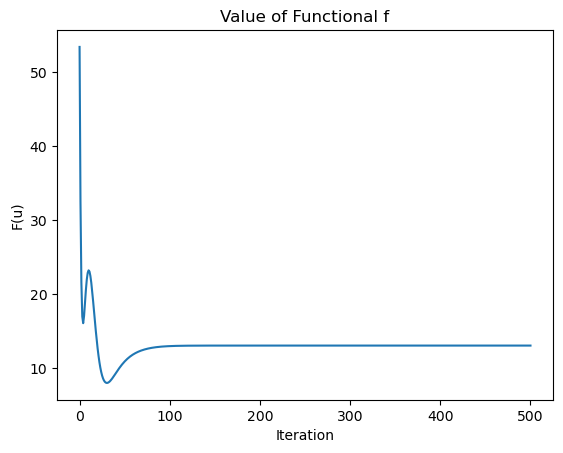

In [10]:
plt.plot(values)
plt.xlabel("Iteration")
plt.ylabel("F(u)")
plt.title("Value of Functional f")
plt.show()

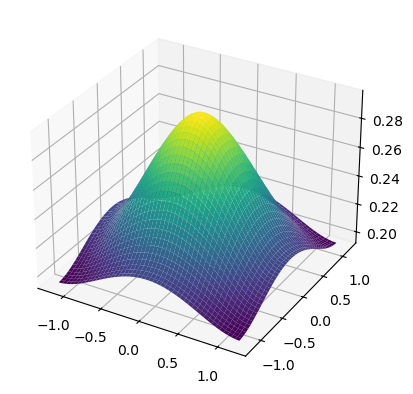

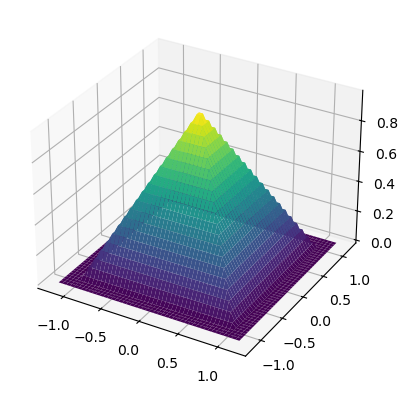

In [11]:
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(X,Y,x, cmap='viridis')
plt.show()

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(X,Y,V, cmap='viridis')
plt.show()

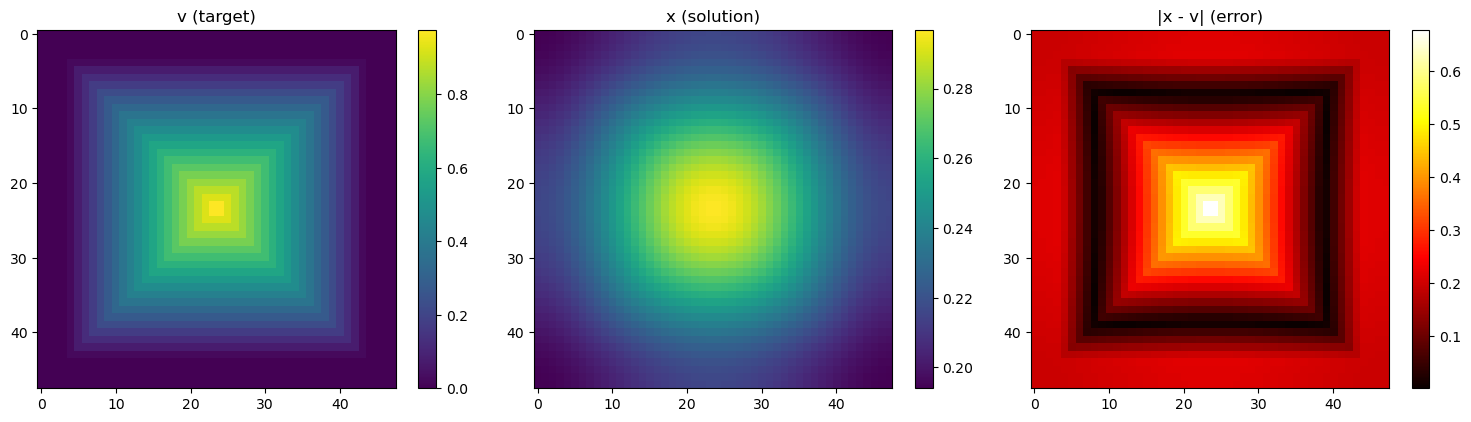

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

im0 = axes[0].imshow(v.asarray(),               cmap='viridis')
axes[0].set_title("v (target)")
plt.colorbar(im0, ax=axes[0])

im1 = axes[1].imshow(x.asarray(),               cmap='viridis')
axes[1].set_title("x (solution)")
plt.colorbar(im1, ax=axes[1])

im2 = axes[2].imshow(np.abs(x.asarray() - v.asarray()), cmap='hot')
axes[2].set_title("|x - v| (error)")
plt.colorbar(im2, ax=axes[2])

plt.tight_layout()
plt.show()